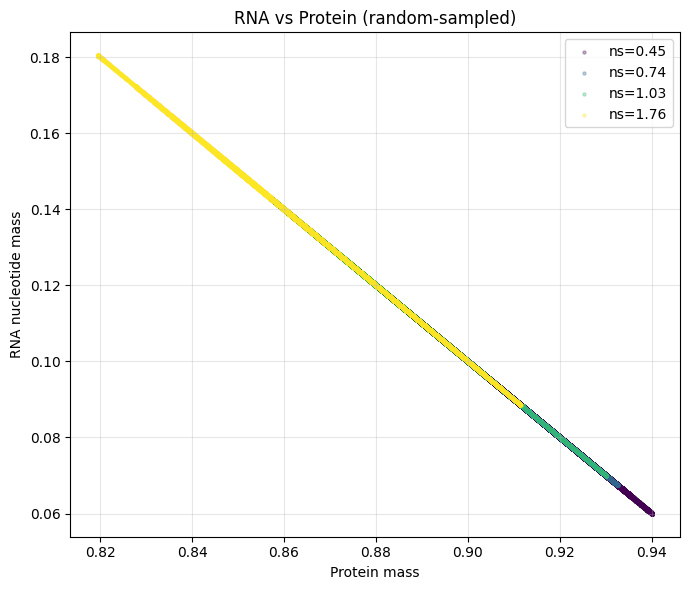

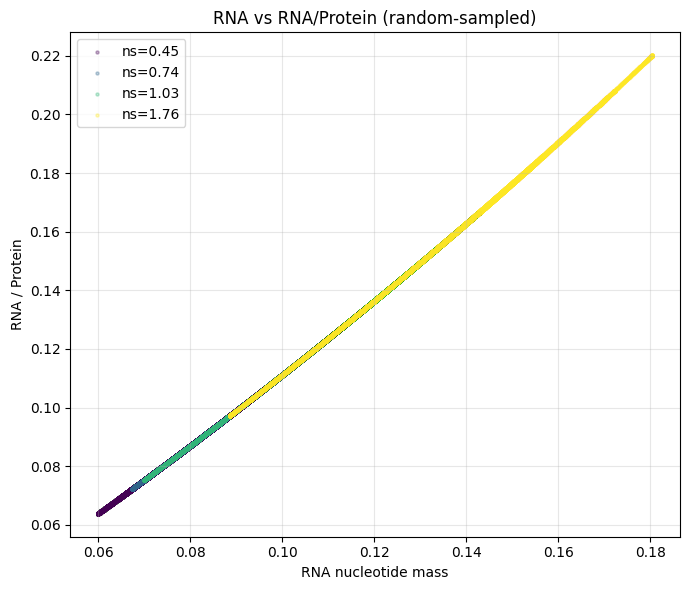

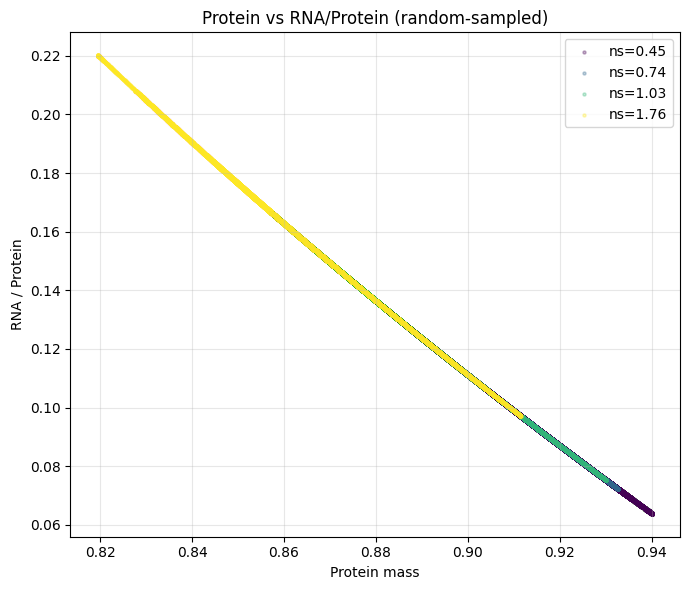

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# Simulation files
# --------------------------------------------------------------
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0    # ribosomal protein size (AA)
NX = 300.0     # non-ribosomal protein size (AA)
BURN_IN = 1000.0

# --------------------------------------------------------------
# Correct mRNA lengths (AA)
# --------------------------------------------------------------
MRNA_LENGTHS_AA = {
    "mm": NX,   # 300 AA
    "mt": NX,
    "mq": NX,
    "mr": NR    # 7549 AA
}

# Corrected rRNA length per ribosome
RIBO_RNA_NT = 4565


# --------------------------------------------------------------
# Load Arrow
# --------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()


# --------------------------------------------------------------
# Compute protein mass ONLY (simulation mass — unchanged)
# --------------------------------------------------------------
def compute_protein_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    prot_mass = NX * (q+et+em)

    return ribo_mass + prot_mass, prot_mass


# --------------------------------------------------------------
# Compute RNA nucleotide mass (correct method)
# --------------------------------------------------------------
def compute_RNA_nt(df, mrna_lengths_aa, ribo_rna_nt=RIBO_RNA_NT):

    # Free + bound mRNAs
    mm_tot = df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]
    mt_tot = df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]
    mq_tot = df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]
    mr_tot = df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]

    mm_nt = 3 * mrna_lengths_aa["mm"]
    mt_nt = 3 * mrna_lengths_aa["mt"]
    mq_nt = 3 * mrna_lengths_aa["mq"]
    mr_nt = 3 * mrna_lengths_aa["mr"]

    mRNA_mass = (
        mm_tot * mm_nt +
        mt_tot * mt_nt +
        mq_tot * mq_nt +
        mr_tot * mr_nt
    ).to_numpy()

    # Free + bound ribosomes
    r_tot = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_mass = r_tot * ribo_rna_nt

    return mRNA_mass + rRNA_mass


# --------------------------------------------------------------
# NEW: Correct total mass for analysis
# --------------------------------------------------------------
def compute_total_mass_new(protein_mass, rna_mass_nt):
    return protein_mass + rna_mass_nt


# --------------------------------------------------------------
# Collect simulation data
# --------------------------------------------------------------
RNA_all = {}
PROT_all = {}
RATIO_all = {}

for ns, fn in FILES.items():

    df = load_arrow(fn)
    t = df["timestamp"].values
    df = df.loc[t >= BURN_IN]

    # Mass components
    protein_mass_total, protein_mass_only = compute_protein_mass(df)
    RNA_nt = compute_RNA_nt(df, MRNA_LENGTHS_AA)

    # Correct total mass for analysis
    total_mass = compute_total_mass_new(protein_mass_total, RNA_nt)

    # Fractions
    RNA_m = RNA_nt / total_mass
    PROT_m = protein_mass_total / total_mass
    RATIO = RNA_m / PROT_m

    RNA_all[ns] = RNA_m
    PROT_all[ns] = PROT_m
    RATIO_all[ns] = RATIO


# --------------------------------------------------------------
# Colour map
# --------------------------------------------------------------
ns_list = list(FILES.keys())
COLORS = plt.cm.viridis(np.linspace(0, 1, len(ns_list)))


# --------------------------------------------------------------
# Helper: random sampling
# --------------------------------------------------------------
def random_sample(arr, N=500000):
    arr = np.asarray(arr)
    total = len(arr)
    N = min(N, total)
    idx = np.random.choice(total, size=N, replace=False)
    return arr[idx], idx


# --------------------------------------------------------------
# Plot 1: RNA vs Protein (random sampling)
# --------------------------------------------------------------
plt.figure(figsize=(7,6))
for ns, col in zip(ns_list, COLORS):

    RNA = np.asarray(RNA_all[ns])
    PROT = np.asarray(PROT_all[ns])

    RNA_s, idx = random_sample(RNA)
    PROT_s = PROT[idx]

    plt.scatter(PROT_s, RNA_s, s=5, alpha=0.3, color=col, label=f"ns={ns}")

plt.xlabel("Protein mass")
plt.ylabel("RNA nucleotide mass")
plt.title("RNA vs Protein (random-sampled)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# Plot 2: RNA vs RNA/Protein
# --------------------------------------------------------------
plt.figure(figsize=(7,6))
for ns, col in zip(ns_list, COLORS):

    RNA = np.asarray(RNA_all[ns])
    RATIO = np.asarray(RATIO_all[ns])

    RNA_s, idx = random_sample(RNA)
    RATIO_s = RATIO[idx]

    plt.scatter(RNA_s, RATIO_s, s=5, alpha=0.3, color=col, label=f"ns={ns}")

plt.xlabel("RNA nucleotide mass")
plt.ylabel("RNA / Protein")
plt.title("RNA vs RNA/Protein (random-sampled)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# Plot 3: Protein vs RNA/Protein
# --------------------------------------------------------------
plt.figure(figsize=(7,6))
for ns, col in zip(ns_list, COLORS):

    PROT = np.asarray(PROT_all[ns])
    RATIO = np.asarray(RATIO_all[ns])

    PROT_s, idx = random_sample(PROT)
    RATIO_s = RATIO[idx]

    plt.scatter(PROT_s, RATIO_s, s=5, alpha=0.3, color=col, label=f"ns={ns}")

plt.xlabel("Protein mass")
plt.ylabel("RNA / Protein")
plt.title("Protein vs RNA/Protein (random-sampled)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


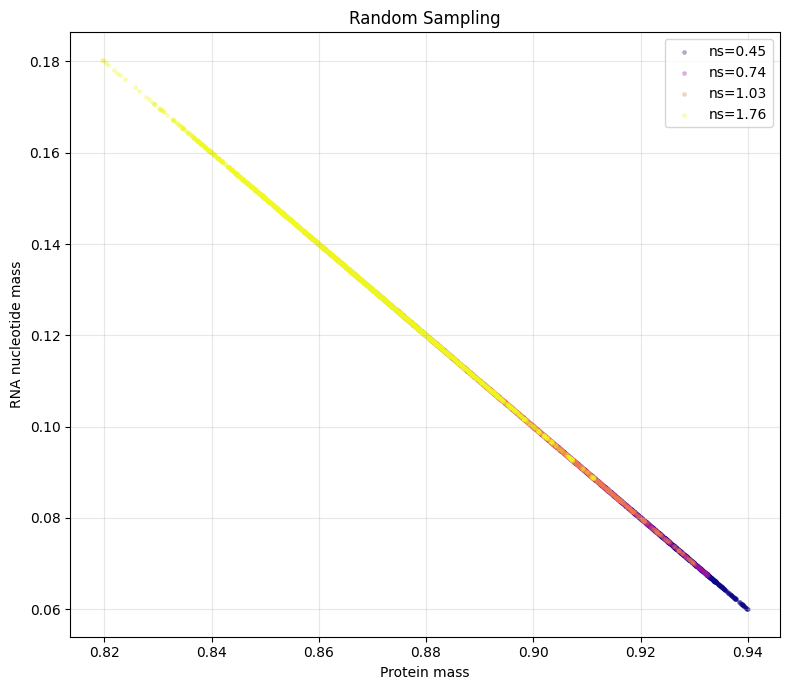

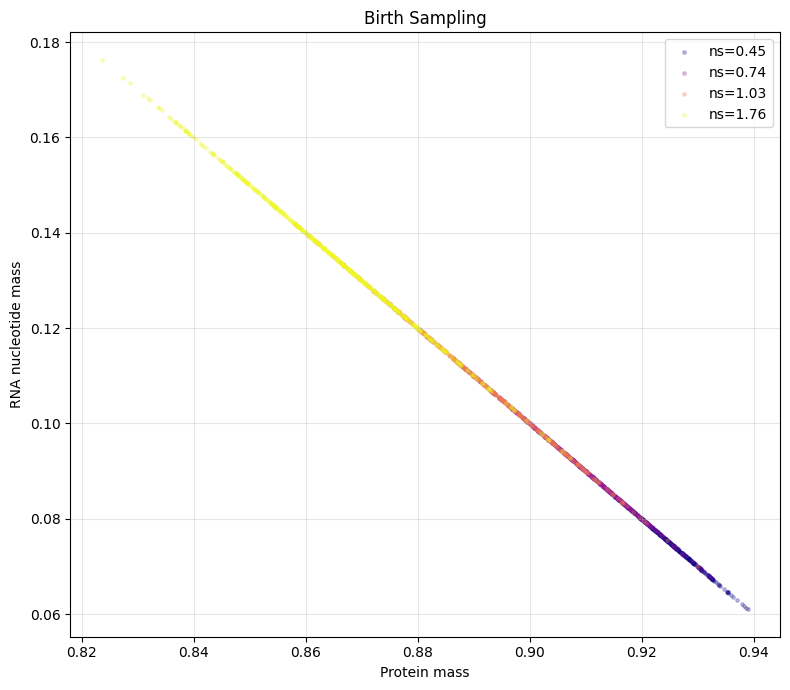

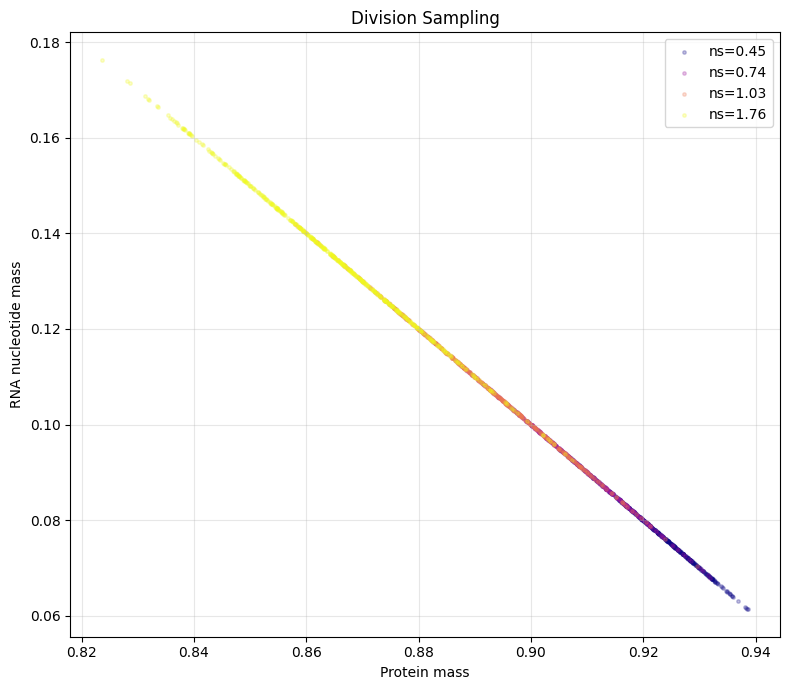

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# Simulation files
# --------------------------------------------------------------
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0       # ribosomal protein AA length
NX = 300.0        # non-ribosomal protein AA length
BURN_IN = 1000.0  # minutes

# --------------------------------------------------------------
# mRNA lengths (AA)
# --------------------------------------------------------------
MRNA_LENGTHS_AA = {
    "mm": NX,     # 300 AA
    "mt": NX,     # 300 AA
    "mq": NX,     # 300 AA
    "mr": NR      # 7549 AA
}

# rRNA nucleotides per ribosome (corrected)
RIBO_RNA_NT = 4565


# --------------------------------------------------------------
# Load Arrow
# --------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()


# --------------------------------------------------------------
# Compute PROTEIN MASS ONLY (model mass — unchanged)
# --------------------------------------------------------------
def compute_protein_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    # ribosomal proteins
    ribo_prot_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)

    # non-ribosomal proteins
    non_ribo_prot = NX * (q+et+em)

    total_protein_mass = ribo_prot_mass + non_ribo_prot
    return total_protein_mass


# --------------------------------------------------------------
# === NEW === Correct RNA nucleotide mass
# --------------------------------------------------------------
def compute_RNA_nt(df, mrna_lengths_aa, ribo_rna_nt=RIBO_RNA_NT):

    # ----- Total free + bound mRNAs -----
    mm_tot = df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]
    mt_tot = df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]
    mq_tot = df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]
    mr_tot = df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]

    # convert AA length → nt length
    mm_nt = 3 * mrna_lengths_aa["mm"]
    mt_nt = 3 * mrna_lengths_aa["mt"]
    mq_nt = 3 * mrna_lengths_aa["mq"]
    mr_nt = 3 * mrna_lengths_aa["mr"]

    mRNA_mass = (
        mm_tot * mm_nt +
        mt_tot * mt_nt +
        mq_tot * mq_nt +
        mr_tot * mr_nt
    ).to_numpy()

    # ----- Total ribosomes (free + bound) -----
    r_tot = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_mass = r_tot * ribo_rna_nt

    # TOTAL RNA MASS (nt)
    return mRNA_mass + rRNA_mass


# --------------------------------------------------------------
# === NEW === CORRECT TOTAL MASS FOR ANALYSIS
# --------------------------------------------------------------
def compute_total_mass_new(protein_mass, rna_mass_nt):
    """
    Protein mass is measured in 'amino-acid units'.
    RNA mass is measured in 'nucleotide units'.

    For now, Andrea said:
    → Don't modify the simulation.
    → For analysis, treat AA mass and NT mass with equal weight.

    So we simply add them.
    """
    return protein_mass + rna_mass_nt


# --------------------------------------------------------------
# === NEW === Detect birth & division sampling
# --------------------------------------------------------------
def detect_birth_division(total_mass):
    birth_idx = []
    division_idx = []
    for i in range(1, len(total_mass)-1):
        if total_mass[i] < total_mass[i-1] and total_mass[i] < total_mass[i+1]:
            birth_idx.append(i)
        if total_mass[i] > total_mass[i-1] and total_mass[i] > total_mass[i+1]:
            division_idx.append(i)
    return np.array(birth_idx), np.array(division_idx)


# --------------------------------------------------------------
# Collect simulation data with corrected RNA + mass
# --------------------------------------------------------------
RNA_all = {}
PROT_all = {}
RATIO_all = {}
BIRTH_points = {}
DIV_points = {}
RAND_points = {}

for ns, fn in FILES.items():

    df = load_arrow(fn)
    t = df["timestamp"].values
    df = df.loc[t >= BURN_IN]

    # --- Protein mass only
    protein_mass = compute_protein_mass(df)

    # --- Correct RNA mass
    RNA_nt = compute_RNA_nt(df, MRNA_LENGTHS_AA)

    # --- NEW total mass for analysis
    total_mass = compute_total_mass_new(protein_mass, RNA_nt)

    # --- Fractions
    RNA_m = RNA_nt / total_mass
    PROT_m = protein_mass / total_mass
    RATIO  = RNA_m / PROT_m

    RNA_all[ns] = np.asarray(RNA_m)
    PROT_all[ns] = np.asarray(PROT_m)
    RATIO_all[ns] = np.asarray(RATIO)

    # --- Birth/division sampling
    birth_idx, division_idx = detect_birth_division(total_mass)
    BIRTH_points[ns] = (PROT_m[birth_idx], RNA_m[birth_idx])
    DIV_points[ns]   = (PROT_m[division_idx], RNA_m[division_idx])

    # --- Random sampling
    N = len(RNA_m)
    idx = np.random.choice(N, size=min(3000, N), replace=False)
    RAND_points[ns] = (PROT_m[idx], RNA_m[idx])


# --------------------------------------------------------------
# Plots (unchanged layouts)
# --------------------------------------------------------------
ns_list = list(FILES.keys())
COLORS = plt.cm.plasma(np.linspace(0, 1, len(ns_list)))


# --------------------------------------------------------------
# RANDOM SAMPLING PLOT
# --------------------------------------------------------------
plt.figure(figsize=(8,7))
for ns, col in zip(ns_list, COLORS):
    plt.scatter(RAND_points[ns][0], RAND_points[ns][1],
                s=6, alpha=0.25, color=col, label=f"ns={ns}")

plt.xlabel("Protein mass")
plt.ylabel("RNA nucleotide mass")
plt.title("Random Sampling")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# BIRTH SAMPLING PLOT
# --------------------------------------------------------------
plt.figure(figsize=(8,7))
for ns, col in zip(ns_list, COLORS):
    plt.scatter(BIRTH_points[ns][0], BIRTH_points[ns][1],
                s=6, alpha=0.25, color=col, label=f"ns={ns}")

plt.xlabel("Protein mass")
plt.ylabel("RNA nucleotide mass")
plt.title("Birth Sampling")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# DIVISION SAMPLING PLOT
# --------------------------------------------------------------
plt.figure(figsize=(8,7))
for ns, col in zip(ns_list, COLORS):
    plt.scatter(DIV_points[ns][0], DIV_points[ns][1],
                s=6, alpha=0.25, color=col, label=f"ns={ns}")

plt.xlabel("Protein mass")
plt.ylabel("RNA nucleotide mass")
plt.title("Division Sampling")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


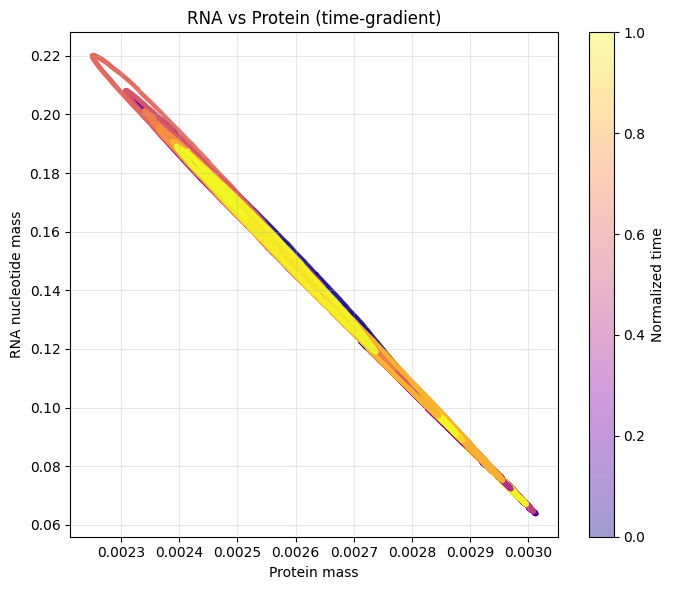

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# Simulation files
# --------------------------------------------------------------
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0    # ribosomal protein size (AA)
NX = 300.0     # non-ribosomal protein size (AA)
BURN_IN = 1000.0

# --------------------------------------------------------------
# Correct mRNA lengths (AA)
# --------------------------------------------------------------
MRNA_LENGTHS_AA = {
    "mm": NX,
    "mt": NX,
    "mq": NX,
    "mr": NR
}

# Corrected rRNA length per ribosome
RIBO_RNA_NT = 4565

# Colormap
CMAP = plt.cm.plasma

# --------------------------------------------------------------
# Load Arrow
# --------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# --------------------------------------------------------------
# Protein mass (simulation definition)
# --------------------------------------------------------------
def compute_protein(df):
    r   = df["r(t)"].to_numpy()
    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()


    return (r+q+et+em)

# --------------------------------------------------------------
# RNA nucleotide mass (correct)
# --------------------------------------------------------------
def compute_RNA_nt(df, mrna_lengths_aa, ribo_rna_nt=RIBO_RNA_NT):

    mm_tot = df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]
    mt_tot = df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]
    mq_tot = df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]
    mr_tot = df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]

    mm_nt = 3 * mrna_lengths_aa["mm"]
    mt_nt = 3 * mrna_lengths_aa["mt"]
    mq_nt = 3 * mrna_lengths_aa["mq"]
    mr_nt = 3 * mrna_lengths_aa["mr"]

    mRNA_mass = (
        mm_tot * mm_nt +
        mt_tot * mt_nt +
        mq_tot * mq_nt +
        mr_tot * mr_nt
    ).to_numpy()

    r_tot = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_mass = r_tot * ribo_rna_nt

    return mRNA_mass + rRNA_mass

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    prot_mass = NX * (q+et+em)

    total_mass = ribo_mass + prot_mass
    return total_mass
# --------------------------------------------------------------
# Time-gradient plot
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

for ns, fn in FILES.items():

    df = load_arrow(fn)

    # Burn-in removal
    t = df["timestamp"].values
    df = df.loc[t >= BURN_IN]

    # Masses
    total_mass = compute_mass(df)
    RNA = compute_RNA_nt(df, MRNA_LENGTHS_AA) / total_mass
    PROT = compute_protein(df) / total_mass

    # Normalized time
    T = df["timestamp"].values
    T_norm = (T - T.min()) / (T.max() - T.min() + 1e-12)

    sc = ax.scatter(
        PROT,
        RNA,
        c=T_norm,
        cmap=CMAP,
        s=6,
        alpha=0.4
    )

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Normalized time")

ax.set_xlabel("Protein mass")
ax.set_ylabel("RNA nucleotide mass")
ax.set_title("RNA vs Protein (time-gradient)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


ns=0.45, number of minima detected: 493


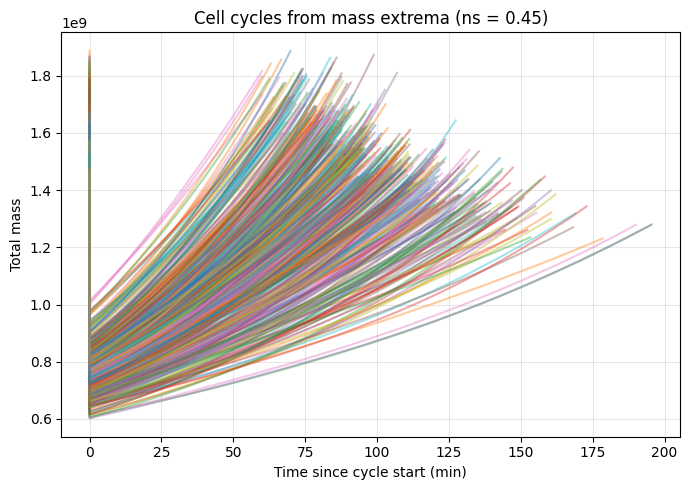

ns=0.74, number of minima detected: 491


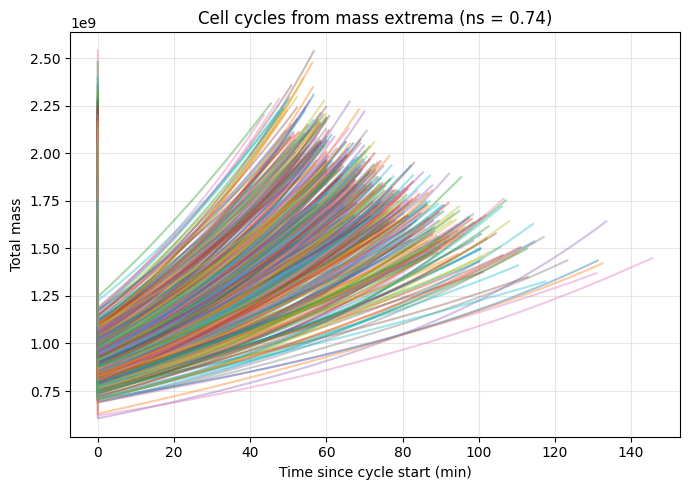

ns=1.03, number of minima detected: 488


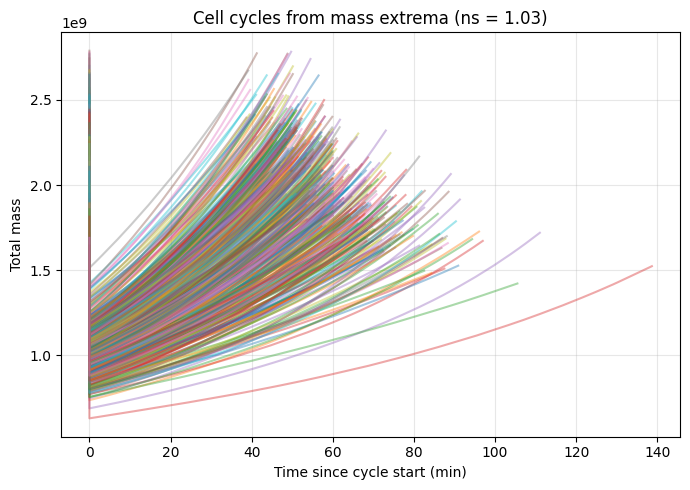

ns=1.76, number of minima detected: 487


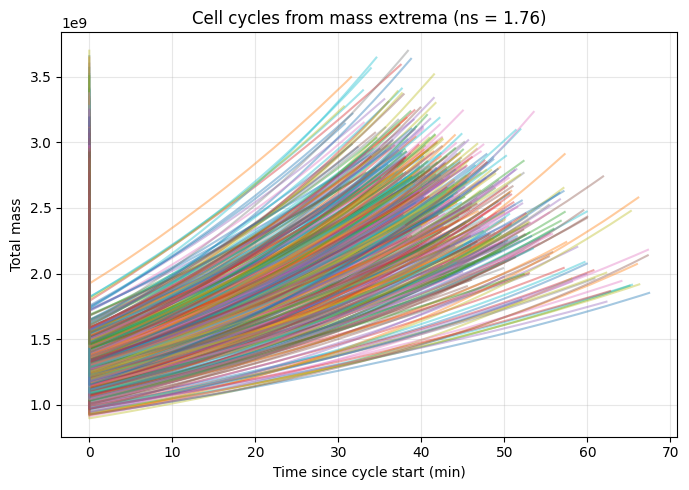

In [1]:
# === Empirical cell-cycle segmentation from mass extrema (one cell) ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
from scipy.signal import find_peaks

# -------------------- PARAMETERS --------------------
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0
NX = 300.0
BURN_IN = 1000.0          # minutes
SMOOTH_WINDOW = 51        # must be odd
MIN_CYCLE_TIME = 20.0    # minutes

# -------------------- HELPERS --------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_total_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    nonr = NX * (q+et+em)
    return ribo + nonr

# -------------------- MAIN --------------------
for ns, fn in FILES.items():

    df = load_arrow(fn)
    t = df["timestamp"].to_numpy()

    mask = t >= BURN_IN
    df = df.loc[mask]
    t = t[mask]

    mass = compute_total_mass(df)

    # smooth mass to suppress noise
    kernel = np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW
    mass_smooth = np.convolve(mass, kernel, mode="same")

    # detect local minima (division-like points)
    minima, _ = find_peaks(mass, distance=20)

    # build cycles between successive minima
    cycles = []
    for i in range(len(minima) - 1):
        i0, i1 = minima[i], minima[i+1]
        if t[i1] - t[i0] >= MIN_CYCLE_TIME:
            cycles.append((i0, i1))
    print(f"ns={ns}, number of minima detected: {len(minima)}")


    # plot cycles
    plt.figure(figsize=(7,5))
    for i0, i1 in cycles:
        plt.plot(t[i0:i1] - t[i0], mass[i0:i1], alpha=0.4)

    plt.xlabel("Time since cycle start (min)")
    plt.ylabel("Total mass")
    plt.title(f"Cell cycles from mass extrema (ns = {ns})")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


ns=0.45, cycles plotted: 491


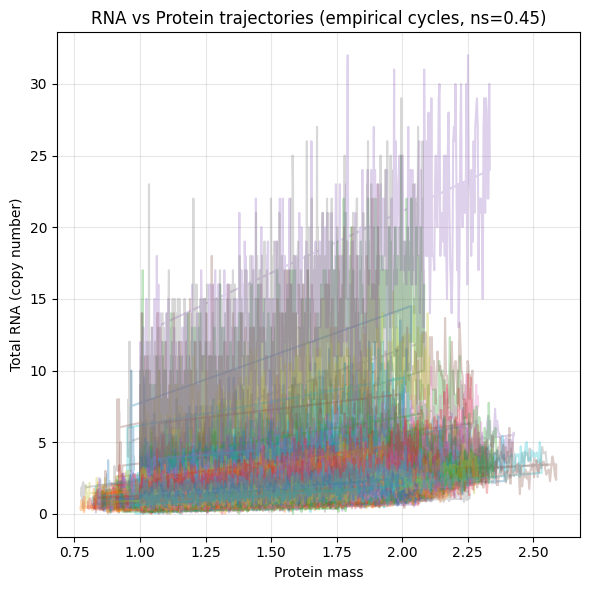

ns=0.74, cycles plotted: 489


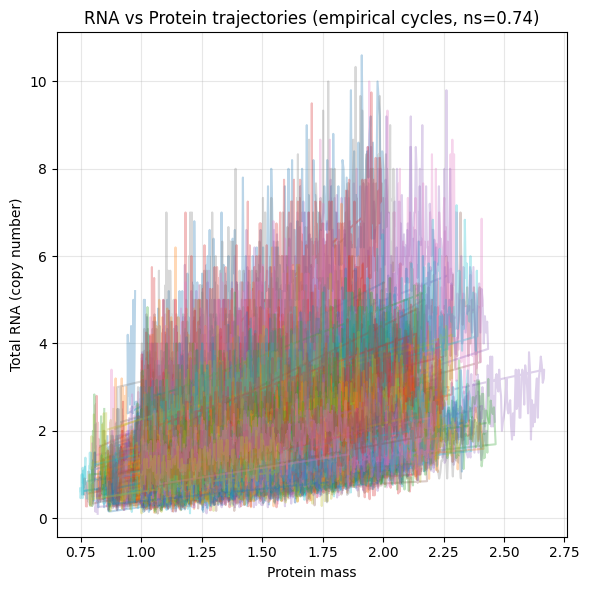

ns=1.03, cycles plotted: 486


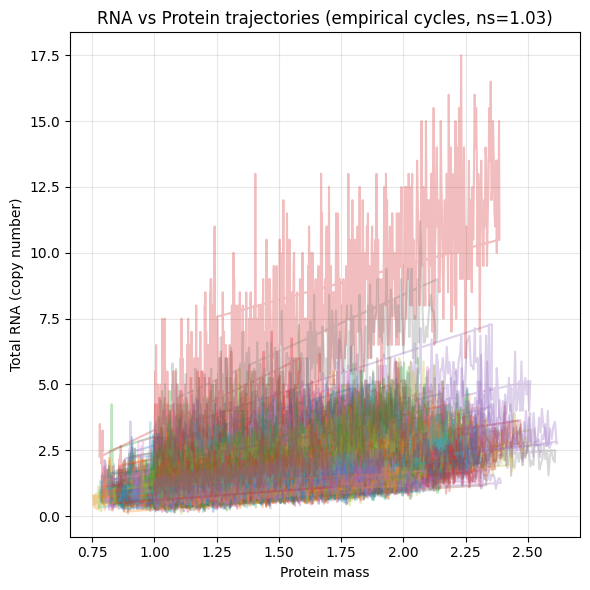

ns=1.76, cycles plotted: 485


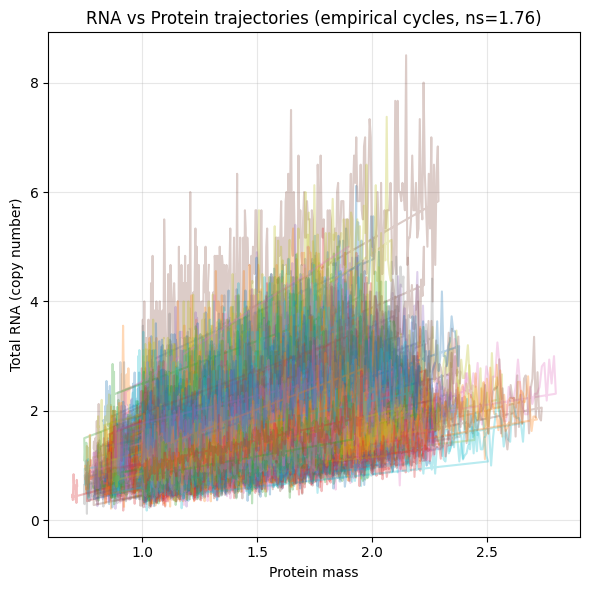

In [3]:
# === RNA vs Protein trajectories segmented by mass extrema (one cell) ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
from scipy.signal import find_peaks

# -------------------- PARAMETERS --------------------
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0
NX = 300.0
BURN_IN = 1000.0
SMOOTH_WINDOW = 31
MIN_CYCLE_TIME = 20.0   # minutes

# -------------------- HELPERS --------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein_masses(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_prot = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    nonribo   = NX * (q+et+em)

    return ribo_prot, nonribo, ribo_prot + nonribo

def compute_RNA_copy_number(df):
    RNA = np.zeros(len(df))
    for col in ["mm(t)", "mt(t)", "mq(t)", "mr(t)"]:
        RNA += df[col].to_numpy()
    return RNA

# -------------------- MAIN --------------------
for ns, fn in FILES.items():

    df = load_arrow(fn)
    t = df["timestamp"].to_numpy()

    mask = t >= BURN_IN
    df = df.loc[mask]
    t = t[mask]

    ribo_prot, nonribo_prot, protein_mass = compute_protein_masses(df)
    RNA = compute_RNA_copy_number(df)

    # total mass for extrema detection
    total_mass = protein_mass

    # smooth mass
    kernel = np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW
    mass_smooth = np.convolve(total_mass, kernel, mode="same")

    # detect local minima
    minima, _ = find_peaks(-mass_smooth, distance=20)

    # build cycles
    cycles = []
    for i in range(len(minima) - 1):
        i0, i1 = minima[i], minima[i+1]
        if t[i1] - t[i0] >= MIN_CYCLE_TIME:
            cycles.append((i0, i1))

    print(f"ns={ns}, cycles plotted: {len(cycles)}")

    # plot RNA vs protein trajectories
    plt.figure(figsize=(6,6))
    for i0, i1 in cycles:
        plt.plot(
            protein_mass[i0:i1] / protein_mass[i0],
            RNA[i0:i1] / (RNA[i0] + 1e-6),
            alpha=0.3
        )


    plt.xlabel("Protein mass")
    plt.ylabel("Total RNA (copy number)")
    plt.title(f"RNA vs Protein trajectories (empirical cycles, ns={ns})")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


ns=0.45, cycles used: 491


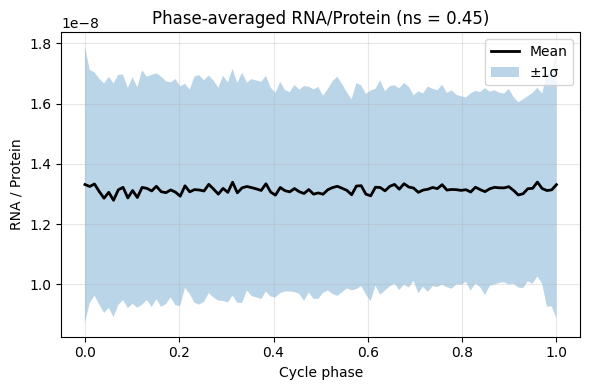

ns=0.74, cycles used: 489


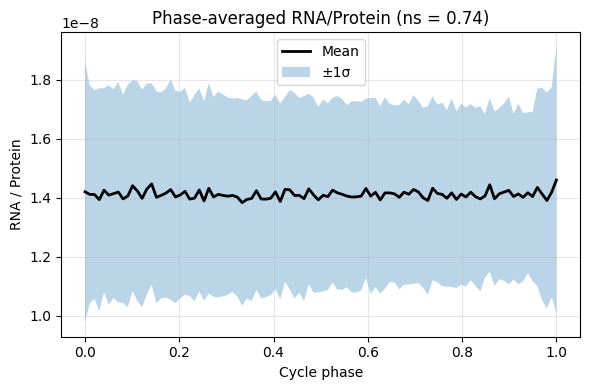

ns=1.03, cycles used: 486


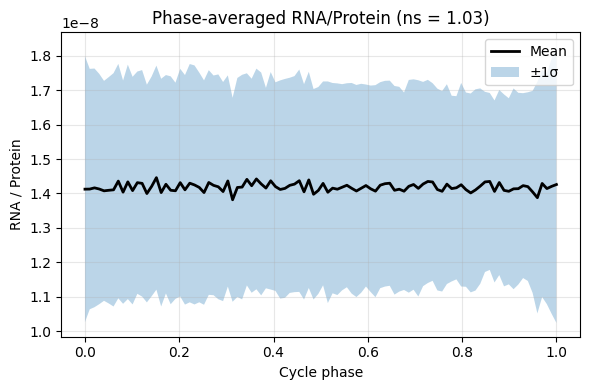

ns=1.76, cycles used: 485


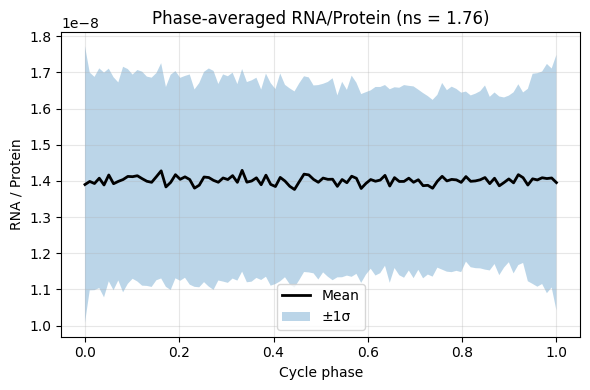

: 

In [ ]:
# === Phase-normalized average RNA/Protein over empirical cycles ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# -------------------- PARAMETERS --------------------
FILES = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NR = 7549.0
NX = 300.0
BURN_IN = 1000.0
SMOOTH_WINDOW = 31
MIN_CYCLE_TIME = 20.0     # minutes
N_PHASE = 100             # phase resolution

# -------------------- HELPERS --------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    nonr = NX * (q+et+em)
    return ribo + nonr

def compute_RNA(df):
    RNA = np.zeros(len(df))
    for col in ["mm(t)", "mt(t)", "mq(t)", "mr(t)"]:
        RNA += df[col].to_numpy()
    return RNA

# -------------------- MAIN --------------------
for ns, fn in FILES.items():

    df = load_arrow(fn)
    t = df["timestamp"].to_numpy()

    mask = t >= BURN_IN
    df = df.loc[mask]
    t = t[mask]

    protein_mass = compute_protein_mass(df)
    RNA = compute_RNA(df)

    # detect empirical cycles via mass minima
    kernel = np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW
    mass_smooth = np.convolve(protein_mass, kernel, mode="same")
    minima, _ = find_peaks(-mass_smooth, distance=20)

    cycles = []
    for i in range(len(minima) - 1):
        i0, i1 = minima[i], minima[i+1]
        if t[i1] - t[i0] >= MIN_CYCLE_TIME:
            cycles.append((i0, i1))

    print(f"ns={ns}, cycles used: {len(cycles)}")

    # phase-normalize RNA/protein trajectories
    phases = np.linspace(0, 1, N_PHASE)
    aligned = []

    for i0, i1 in cycles:
        rp = RNA[i0:i1] / protein_mass[i0:i1]
        phase_local = np.linspace(0, 1, len(rp))

        f = interp1d(
            phase_local,
            rp,
            bounds_error=False,
            fill_value="extrapolate"
        )
        aligned.append(f(phases))

    aligned = np.array(aligned)
    mean = np.mean(aligned, axis=0)
    std  = np.std(aligned, axis=0)

    # plot
    plt.figure(figsize=(6,4))
    plt.plot(phases, mean, color="black", lw=2, label="Mean")
    plt.fill_between(phases, mean-std, mean+std, alpha=0.3, label="±1σ")

    plt.xlabel("Cycle phase")
    plt.ylabel("RNA / Protein")
    plt.title(f"Phase-averaged RNA/Protein (ns = {ns})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
